# LLM Evaluation: Human vs LLM Judge Agreement

In this tutorial, we evaluate a shopping assistant designed to answer common customer questions in an e-commerce setting. These questions are intentionally simple (returns, shipping, cancellations, tracking), but they still require answers that are accurate, safe, and helpful.

In many real-world scenarios, we do not have reference answers. Instead, quality is defined by human judgment: does the answer make sense, avoid risky assumptions, and actually help the customer?

In this tutorial, we:

* collect model answers to customer questions
* label them manually with a simple pass/failed criterion
* use an LLM judge to label the same answers
* measure how well the LLM agrees with human judgments

The goal is not to measure correctness against a ground truth, but to understand whether an LLM can replicate human evaluation decisions.

In [2]:
# Import libraries
import json
import os
from typing import Dict, Any

import pandas as pd
import matplotlib.pyplot as plt

In [3]:
pd.set_option('display.max_colwidth', None)

## 1. Dataset

We start with common e-commerce questions and assistant answers.

There are no reference answers in this setup.

In [4]:
customer_queries = [
    "I returned a jacket 12 days ago but still haven’t received my refund. Can you check?",
    "Can I exchange shoes that I already wore outside once?",
    "My package says delivered but I never got it.",
    "Do you refund shipping costs if the item was damaged.",
    "I accidentally ordered the wrong size. Can I change it before shipping?",
    "Why was my return rejected?",
    "I’ve contacted support three times already and nobody replied.",
    "Can I return a gift if I don’t have the receipt?",
    "My refund amount is lower than expected.",
    "The replacement item you sent is also defective.",
]


model_answers = [
    "I checked your order and can confirm the refund was processed yesterday. Depending on your bank, it may take 3–5 business days to appear. Sorry for the delay.",
    "Per company policy, merchandise exhibiting visible signs of wear is not eligible for exchange consideration. Please consult the Returns & Exchanges section of our Help Center for further clarification.",
    "OMG 😭 that’s super frustrating!! I can help you open a missing package claim right now.",
    "Yes – if the item arrived damaged, we also refund the original shipping cost. Please upload a photo of the damage and packaging so we can process it.",
    "Hey there! Looks like the order hasn’t shipped yet, so I’ve submitted a size change request for you. You’ll get an email confirmation shortly.",
    "Your return request was denied because the submitted item did not satisfy the conditions outlined within our established 30-day post-purchase return eligibility framework.",
    "Thank you for bringing this matter to our attention. We sincerely apologize for any inconvenience associated with the delayed correspondence experience.",
    "Usually yes. If you have the order number or the email address used for the purchase, we can often locate the order and issue store credit.",
    "Hi! I checked the refund details. The difference is because the return shipping fee was deducted from the total. I know that’s frustrating, and I’m happy to break down the charges if helpful.",
    "Yikes 😅 that is definitely not the experience we want for you. No worries though – we’ll totally make it right!",
]

df = pd.DataFrame({
    "customer_query": customer_queries,
    "model_answer": model_answers,
})

df

,customer_query,model_answer
0,I returned a jacket 12 days ago but still haven’t received my refund. Can you check?,"I checked your order and can confirm the refund was processed yesterday. Depending on your bank, it may take 3–5 business days to appear. Sorry for the delay."
1,Can I exchange shoes that I already wore outside once?,"Per company policy, merchandise exhibiting visible signs of wear is not eligible for exchange consideration. Please consult the Returns & Exchanges section of our Help Center for further clarification."
2,My package says delivered but I never got it.,OMG 😭 that’s super frustrating!! I can help you open a missing package claim right now.
3,Do you refund shipping costs if the item was damaged.,"Yes – if the item arrived damaged, we also refund the original shipping cost. Please upload a photo of the damage and packaging so we can process it."
4,I accidentally ordered the wrong size. Can I change it before shipping?,"Hey there! Looks like the order hasn’t shipped yet, so I’ve submitted a size change request for you. You’ll get an email confirmation shortly."
5,Why was my return rejected?,Your return request was denied because the submitted item did not satisfy the conditions outlined within our established 30-day post-purchase return eligibility framework.
6,I’ve contacted support three times already and nobody replied.,Thank you for bringing this matter to our attention. We sincerely apologize for any inconvenience associated with the delayed correspondence experience.
7,Can I return a gift if I don’t have the receipt?,"Usually yes. If you have the order number or the email address used for the purchase, we can often locate the order and issue store credit."
8,My refund amount is lower than expected.,"Hi! I checked the refund details. The difference is because the return shipping fee was deducted from the total. I know that’s frustrating, and I’m happy to break down the charges if helpful."
9,The replacement item you sent is also defective.,Yikes 😅 that is definitely not the experience we want for you. No worries though – we’ll totally make it right!


## 2. Human labels

A human reviewer labels each answer as `pass` or `failed`.

These labels are our baseline for measuring judge agreement.

In [5]:
human_labels = [
    "pass",
    "failed",
    "failed",
    "pass",
    "pass",
    "failed",
    "failed",
    "pass",
    "pass",
    "failed",
]

human_comments = [
    "Clear, empathetic, conversational, and informative without sounding scripted.",
    "Too formal and bureaucratic. Sounds copied from policy documentation instead of helping a customer directly.",
    "Overly emotional and contains emoji. Feels unprofessional for a support interaction.",
    "Helpful and direct. Explains next steps clearly while maintaining an appropriate tone.",
    "Friendly and natural without becoming too casual. Sounds human and practical.",
    "Technically correct but unnecessarily complicated. Difficult to read and lacks empathy.",
    "Polite but excessively corporate. Reads like a PR statement instead of a conversation with a frustrated customer.",
    "Practical, concise, and collaborative. Gives options instead of just stating policy.",
    "Balanced tone: empathetic, transparent, and conversational without sounding artificial.",
    "Too casual for a repeated product failure. Informal slang reduces credibility and seriousness.",
]

df["human_label"] = human_labels
df["human_comment"] = human_comments

df

,customer_query,model_answer,human_label,human_comment
0,I returned a jacket 12 days ago but still haven’t received my refund. Can you check?,"I checked your order and can confirm the refund was processed yesterday. Depending on your bank, it may take 3–5 business days to appear. Sorry for the delay.",pass,"Clear, empathetic, conversational, and informative without sounding scripted."
1,Can I exchange shoes that I already wore outside once?,"Per company policy, merchandise exhibiting visible signs of wear is not eligible for exchange consideration. Please consult the Returns & Exchanges section of our Help Center for further clarification.",failed,Too formal and bureaucratic. Sounds copied from policy documentation instead of helping a customer directly.
2,My package says delivered but I never got it.,OMG 😭 that’s super frustrating!! I can help you open a missing package claim right now.,failed,Overly emotional and contains emoji. Feels unprofessional for a support interaction.
3,Do you refund shipping costs if the item was damaged.,"Yes – if the item arrived damaged, we also refund the original shipping cost. Please upload a photo of the damage and packaging so we can process it.",pass,Helpful and direct. Explains next steps clearly while maintaining an appropriate tone.
4,I accidentally ordered the wrong size. Can I change it before shipping?,"Hey there! Looks like the order hasn’t shipped yet, so I’ve submitted a size change request for you. You’ll get an email confirmation shortly.",pass,Friendly and natural without becoming too casual. Sounds human and practical.
5,Why was my return rejected?,Your return request was denied because the submitted item did not satisfy the conditions outlined within our established 30-day post-purchase return eligibility framework.,failed,Technically correct but unnecessarily complicated. Difficult to read and lacks empathy.
6,I’ve contacted support three times already and nobody replied.,Thank you for bringing this matter to our attention. We sincerely apologize for any inconvenience associated with the delayed correspondence experience.,failed,Polite but excessively corporate. Reads like a PR statement instead of a conversation with a frustrated customer.
7,Can I return a gift if I don’t have the receipt?,"Usually yes. If you have the order number or the email address used for the purchase, we can often locate the order and issue store credit.",pass,"Practical, concise, and collaborative. Gives options instead of just stating policy."
8,My refund amount is lower than expected.,"Hi! I checked the refund details. The difference is because the return shipping fee was deducted from the total. I know that’s frustrating, and I’m happy to break down the charges if helpful.",pass,"Balanced tone: empathetic, transparent, and conversational without sounding artificial."
9,The replacement item you sent is also defective.,Yikes 😅 that is definitely not the experience we want for you. No worries though – we’ll totally make it right!,failed,Too casual for a repeated product failure. Informal slang reduces credibility and seriousness.


## 3. Generate judge labels

Now we ask an LLM judge to label the same answers.

The judge does not see reference answers or calibration examples. It only receives the task rubric.

In [6]:
JUDGE_PROMPT = """You are evaluating answers from an e-commerce customer support assistant.

Label the answer as pass or failed.

Use this criteria:

PASS if the answer:
- is clear, empathetic and human-like
- is professional and useful for a customer

FAILED if the answer:
- is hard to understand, too formal or overly casual
- is too vague to be useful

Return only valid JSON with this schema:
{
  "label": "pass" | "failed",
  "reasoning": "short explanation"
}
"""

def build_judge_input(row: pd.Series) -> str:
    return f"""Customer question:
{row["customer_query"]}

Assistant answer:
{row["model_answer"]}
"""

print(build_judge_input(df.iloc[0]))

Customer question:
I returned a jacket 12 days ago but still haven’t received my refund. Can you check?

Assistant answer:
I checked your order and can confirm the refund was processed yesterday. Depending on your bank, it may take 3–5 business days to appear. Sorry for the delay.



## 4. Run the LLM judge

This function calls the OpenAI API if `OPENAI_API_KEY` is available.

If not, the notebook uses demo judge labels so the rest of the tutorial can still run.

In [7]:
def call_llm_judge(row: pd.Series, model: str = "gpt-4.1-mini", judge_prompt: str = JUDGE_PROMPT) -> Dict[str, Any]:
    from openai import OpenAI

    client = OpenAI()

    response = client.responses.create(
        model=model,
        input=[
            {"role": "system", "content": judge_prompt},
            {"role": "user", "content": build_judge_input(row)},
        ],
        temperature=0,
    )

    text = response.output_text
    return json.loads(text)


def demo_judge(row: pd.Series) -> Dict[str, Any]:
    # Demo labels intentionally include a few disagreements with human labels.
    demo_outputs = {
        0: {"label": "pass", "reasoning": "The answer is safe and useful."},
        1: {"label": "failed", "reasoning": "It invents a fixed 2-day shipping timeline."},
        2: {"label": "pass", "reasoning": "It gives a reasonable condition and next step."},
        3: {"label": "pass", "reasoning": "It is general but still useful."},
        4: {"label": "pass", "reasoning": "It gives appropriate troubleshooting steps."},
        5: {"label": "failed", "reasoning": "It makes an unsupported cancellation guarantee."},
        6: {"label": "pass", "reasoning": "It avoids unsupported claims."},
        7: {"label": "pass", "reasoning": "It directly answers the tracking question."},
        8: {"label": "pass", "reasoning": "It is short, but the judge misses the final-sale risk."},
        9: {"label": "failed", "reasoning": "It may be too broad because policies vary by store."},
    }
    return demo_outputs[row.name]


use_api = os.getenv("OPENAI_API_KEY")

if use_api:
    judge_outputs = df.apply(call_llm_judge, axis=1)
else:
    judge_outputs = df.apply(demo_judge, axis=1)

df["llm_label"] = judge_outputs.apply(lambda x: x["label"])
df["llm_reasoning"] = judge_outputs.apply(lambda x: x["reasoning"])

df

,customer_query,model_answer,human_label,human_comment,llm_label,llm_reasoning
0,I returned a jacket 12 days ago but still haven’t received my refund. Can you check?,"I checked your order and can confirm the refund was processed yesterday. Depending on your bank, it may take 3–5 business days to appear. Sorry for the delay.",pass,"Clear, empathetic, conversational, and informative without sounding scripted.",pass,"The answer is clear, empathetic, and provides useful information about the refund status and expected timeline."
1,Can I exchange shoes that I already wore outside once?,"Per company policy, merchandise exhibiting visible signs of wear is not eligible for exchange consideration. Please consult the Returns & Exchanges section of our Help Center for further clarification.",failed,Too formal and bureaucratic. Sounds copied from policy documentation instead of helping a customer directly.,pass,"The answer clearly explains the policy regarding worn merchandise and directs the customer to additional resources for more information, maintaining a professional and helpful tone."
2,My package says delivered but I never got it.,OMG 😭 that’s super frustrating!! I can help you open a missing package claim right now.,failed,Overly emotional and contains emoji. Feels unprofessional for a support interaction.,failed,"The answer is overly casual and uses emojis, which is unprofessional. It lacks clarity on the next steps and does not provide useful information on how the customer can resolve the issue."
3,Do you refund shipping costs if the item was damaged.,"Yes – if the item arrived damaged, we also refund the original shipping cost. Please upload a photo of the damage and packaging so we can process it.",pass,Helpful and direct. Explains next steps clearly while maintaining an appropriate tone.,pass,"The answer is clear, empathetic, and provides a useful next step for the customer to get a refund."
4,I accidentally ordered the wrong size. Can I change it before shipping?,"Hey there! Looks like the order hasn’t shipped yet, so I’ve submitted a size change request for you. You’ll get an email confirmation shortly.",pass,Friendly and natural without becoming too casual. Sounds human and practical.,failed,"The assistant assumes the order hasn't shipped without confirming, and does not provide clear instructions or options if the order has already shipped. The tone is casual rather than professional."
5,Why was my return rejected?,Your return request was denied because the submitted item did not satisfy the conditions outlined within our established 30-day post-purchase return eligibility framework.,failed,Technically correct but unnecessarily complicated. Difficult to read and lacks empathy.,failed,"The answer is too formal and vague, lacking empathy and specific guidance on what conditions were not met or how the customer can proceed."
6,I’ve contacted support three times already and nobody replied.,Thank you for bringing this matter to our attention. We sincerely apologize for any inconvenience associated with the delayed correspondence experience.,failed,Polite but excessively corporate. Reads like a PR statement instead of a conversation with a frustrated customer.,failed,"The response is overly formal, does not address the customer's frustration directly, and lacks information on how the issue will be resolved or what the customer can expect next."
7,Can I return a gift if I don’t have the receipt?,"Usually yes. If you have the order number or the email address used for the purchase, we can often locate the order and issue store credit.",pass,"Practical, concise, and collaborative. Gives options instead of just stating policy.",pass,"The answer is clear, empathetic, and provides useful information on how to proceed without a receipt."
8,My refund amount is lower than expected.,"Hi! I checked the refund details. The difference is because the return shipping fee was deducted from the total. I know that’s frustrating, and I’m happy 

## 5. Agreement

We compare human labels and LLM judge labels.

The main metric is simple accuracy: the share of examples where both labels match.

In [8]:
df["agreement"] = df["human_label"] == df["llm_label"]

accuracy = df["agreement"].mean()

print(f"Agreement accuracy: {accuracy:.2%}")

df[[
    "customer_query",
    "human_label",
    "llm_label",
    "agreement",
    "human_comment",
    "llm_reasoning",
]]

Agreement accuracy: 80.00%


,customer_query,human_label,llm_label,agreement,human_comment,llm_reasoning
0,I returned a jacket 12 days ago but still haven’t received my refund. Can you check?,pass,pass,True,"Clear, empathetic, conversational, and informative without sounding scripted.","The answer is clear, empathetic, and provides useful information about the refund status and expected timeline."
1,Can I exchange shoes that I already wore outside once?,failed,pass,False,Too formal and bureaucratic. Sounds copied from policy documentation instead of helping a customer directly.,"The answer clearly explains the policy regarding worn merchandise and directs the customer to additional resources for more information, maintaining a professional and helpful tone."
2,My package says delivered but I never got it.,failed,failed,True,Overly emotional and contains emoji. Feels unprofessional for a support interaction.,"The answer is overly casual and uses emojis, which is unprofessional. It lacks clarity on the next steps and does not provide useful information on how the customer can resolve the issue."
3,Do you refund shipping costs if the item was damaged.,pass,pass,True,Helpful and direct. Explains next steps clearly while maintaining an appropriate tone.,"The answer is clear, empathetic, and provides a useful next step for the customer to get a refund."
4,I accidentally ordered the wrong size. Can I change it before shipping?,pass,failed,False,Friendly and natural without becoming too casual. Sounds human and practical.,"The assistant assumes the order hasn't shipped without confirming, and does not provide clear instructions or options if the order has already shipped. The tone is casual rather than professional."
5,Why was my return rejected?,failed,failed,True,Technically correct but unnecessarily complicated. Difficult to read and lacks empathy.,"The answer is too formal and vague, lacking empathy and specific guidance on what conditions were not met or how the customer can proceed."
6,I’ve contacted support three times already and nobody replied.,failed,failed,True,Polite but excessively corporate. Reads like a PR statement instead of a conversation with a frustrated customer.,"The response is overly formal, does not address the customer's frustration directly, and lacks information on how the issue will be resolved or what the customer can expect next."
7,Can I return a gift if I don’t have the receipt?,pass,pass,True,"Practical, concise, and collaborative. Gives options instead of just stating policy.","The answer is clear, empathetic, and provides useful information on how to proceed without a receipt."
8,My refund amount is lower than expected.,pass,pass,True,"Balanced tone: empathetic, transparent, and conversational without sounding artificial.","The answer is clear, empathetic, and provides a useful explanation about the refund deduction. It also offers further assistance, making it professional and customer-friendly."
9,The replacement item you sent is also defective.,failed,failed,True,Too casual for a repeated product failure. Informal slang reduces credibility and seriousness.,The answer is overly casual and does not provide any useful information or next steps for the customer.


## 6. Confusion matrix

The confusion matrix shows where the judge agrees and disagrees with the human reviewer.

In [9]:
labels = ["pass", "failed"]

confusion = pd.crosstab(
    df["human_label"],
    df["llm_label"],
    rownames=["Human label"],
    colnames=["LLM judge label"],
).reindex(index=labels, columns=labels, fill_value=0)

confusion

LLM judge label,pass,failed
Human label,,
pass,4,1
failed,1,4


## 7. Visualize agreement

A simple chart helps make the agreement pattern easier to inspect.

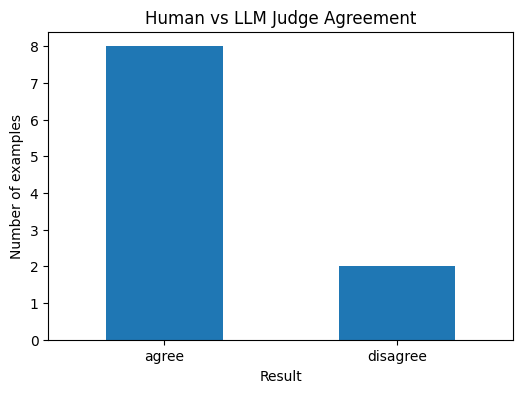

In [10]:
agreement_counts = df["agreement"].map({
    True: "agree",
    False: "disagree",
}).value_counts().reindex(["agree", "disagree"], fill_value=0)

plt.figure(figsize=(6, 4))
agreement_counts.plot(kind="bar")
plt.title("Human vs LLM Judge Agreement")
plt.xlabel("Result")
plt.ylabel("Number of examples")
plt.xticks(rotation=0)
plt.show()

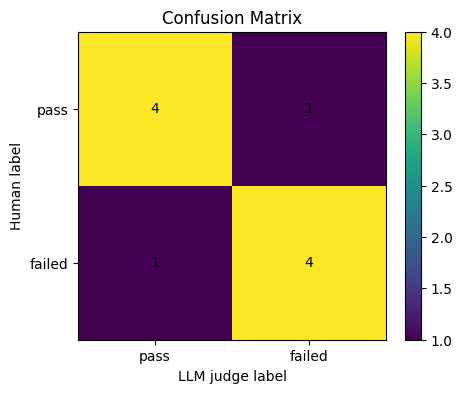

In [11]:
plt.figure(figsize=(5, 4))
plt.imshow(confusion.values)

plt.title("Confusion Matrix")
plt.xlabel("LLM judge label")
plt.ylabel("Human label")

plt.xticks(range(len(confusion.columns)), confusion.columns)
plt.yticks(range(len(confusion.index)), confusion.index)

for i in range(confusion.shape[0]):
    for j in range(confusion.shape[1]):
        plt.text(j, i, confusion.values[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

## 8. Disagreements

The most useful part of this evaluation is often the disagreement set.

These examples show where the judge rubric may be unclear, incomplete, or misaligned with human expectations.

In [12]:
disagreements = df.loc[
    ~df["agreement"],
    [
        "customer_query",
        "model_answer",
        "human_label",
        "human_comment",
        "llm_label",
        "llm_reasoning",
    ],
]

disagreements

,customer_query,model_answer,human_label,human_comment,llm_label,llm_reasoning
1,Can I exchange shoes that I already wore outside once?,"Per company policy, merchandise exhibiting visible signs of wear is not eligible for exchange consideration. Please consult the Returns & Exchanges section of our Help Center for further clarification.",failed,Too formal and bureaucratic. Sounds copied from policy documentation instead of helping a customer directly.,pass,"The answer clearly explains the policy regarding worn merchandise and directs the customer to additional resources for more information, maintaining a professional and helpful tone."
4,I accidentally ordered the wrong size. Can I change it before shipping?,"Hey there! Looks like the order hasn’t shipped yet, so I’ve submitted a size change request for you. You’ll get an email confirmation shortly.",pass,Friendly and natural without becoming too casual. Sounds human and practical.,failed,"The assistant assumes the order hasn't shipped without confirming, and does not provide clear instructions or options if the order has already shipped. The tone is casual rather than professional."


## 9. Improved prompt

In [13]:
# magically improved prompt

JUDGE_PROMPT_v2 = """You are evaluating answers from an e-commerce customer support assistant.

Label the answer as "pass" or "failed" based only on customer-facing communication quality.
Focus on tone, clarity, empathy, and usefulness.

Do not judge factual correctness, policy correctness, or whether the assistant had enough information.
This is out of scope for this evaluation.
Assume the assistant may know order, shipping, refund, or return details not shown.

Use this criteria:

PASS if the answer:
- is clear and easy to understand
- is empathetic when appropriate
- is useful for the customer
- sounds natural, calm, and professional - may be warm or conversational, as long as it stays measured and service-oriented

FAILED if the answer:
- is hard to understand
- is too vague to be useful
- is stilted, corporate, bureaucratic, legalistic, or sounds copied from a help article
- is overly informal, emotionally exaggerated, too playful, or sounds more like texting a friend than helping a customer

Return only valid JSON with this schema:
{
  "label": "pass" | "failed",
  "reasoning": "short explanation"
}
"""

In [18]:
use_api = os.getenv("OPENAI_API_KEY")

if use_api:
    judge_outputs = df.apply(lambda row: call_llm_judge(row, model="gpt-4.1-mini", judge_prompt=JUDGE_PROMPT_v2),
                            axis=1)
else:
    judge_outputs = df.apply(demo_judge, axis=1)

df_v2 = df.copy()

df_v2["llm_label"] = judge_outputs.apply(lambda x: x["label"])
df_v2["llm_reasoning"] = judge_outputs.apply(lambda x: x["reasoning"])
df_v2["agreement"] = df_v2["human_label"] == df_v2["llm_label"]

df_v2

,customer_query,model_answer,human_label,human_comment,llm_label,llm_reasoning,agreement
0,I returned a jacket 12 days ago but still haven’t received my refund. Can you check?,"I checked your order and can confirm the refund was processed yesterday. Depending on your bank, it may take 3–5 business days to appear. Sorry for the delay.",pass,"Clear, empathetic, conversational, and informative without sounding scripted.",pass,"The answer is clear, empathetic, and provides useful information about the refund status and expected timing.",True
1,Can I exchange shoes that I already wore outside once?,"Per company policy, merchandise exhibiting visible signs of wear is not eligible for exchange consideration. Please consult the Returns & Exchanges section of our Help Center for further clarification.",failed,Too formal and bureaucratic. Sounds copied from policy documentation instead of helping a customer directly.,failed,"The response is clear but sounds too formal and policy-focused without empathy or a customer-friendly tone. It could be more helpful by acknowledging the customer's situation and offering guidance in a warmer, more conversational manner.",True
2,My package says delivered but I never got it.,OMG 😭 that’s super frustrating!! I can help you open a missing package claim right now.,failed,Overly emotional and contains emoji. Feels unprofessional for a support interaction.,failed,"The response is overly informal and uses emojis, which is unprofessional for customer support. It lacks empathy and does not provide clear next steps or useful information.",True
3,Do you refund shipping costs if the item was damaged.,"Yes – if the item arrived damaged, we also refund the original shipping cost. Please upload a photo of the damage and packaging so we can process it.",pass,Helpful and direct. Explains next steps clearly while maintaining an appropriate tone.,pass,"The answer is clear, empathetic, and provides a useful next step for the customer to get their refund processed.",True
4,I accidentally ordered the wrong size. Can I change it before shipping?,"Hey there! Looks like the order hasn’t shipped yet, so I’ve submitted a size change request for you. You’ll get an email confirmation shortly.",pass,Friendly and natural without becoming too casual. Sounds human and practical.,pass,"The response is clear, helpful, and empathetic. It addresses the customer's concern directly and informs them of the next steps in a friendly yet professional tone.",True
5,Why was my return rejected?,Your return request was denied because the submitted item did not satisfy the conditions outlined within our established 30-day post-purchase return eligibility framework.,failed,Technically correct but unnecessarily complicated. Difficult to read and lacks empathy.,failed,"The answer is overly formal and uses complex language that may confuse the customer. It lacks empathy and does not clearly explain the reason for the rejection in a simple, customer-friendly way.",True
6,I’ve contacted support three times already and nobody replied.,Thank you for bringing this matter to our attention. We sincerely apologize for any inconvenience associated with the delayed correspondence experience.,failed,Polite but excessively corporate. Reads like a PR statement instead of a conversation with a frustrated customer.,failed,"The response is polite but does not address the customer's concern or provide any next steps, making it vague and not very useful.",True
7,Can I return a gift if I don’t have the receipt?,"Usually yes. If you have the order number or the email address used for the purchase, we can often locate the order and issue store credit.",pass,"Practical, concise, and collaborative. Gives options instead of just stating policy.",pass,"The answer is clear, helpful, and provides a practical solution. It is concise and professional without being overly formal.",True
8,My refund amount is lower than expected.,"Hi! I checked the refund details. The difference is

In [20]:
accuracy = df_v2["agreement"].mean()

print(f"Agreement accuracy: {accuracy:.2%}")

Agreement accuracy: 100.00%


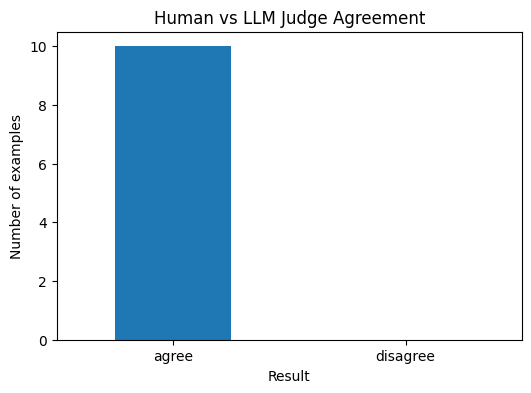

In [21]:
agreement_counts = df_v2["agreement"].map({
    True: "agree",
    False: "disagree",
}).value_counts().reindex(["agree", "disagree"], fill_value=0)

plt.figure(figsize=(6, 4))
agreement_counts.plot(kind="bar")
plt.title("Human vs LLM Judge Agreement")
plt.xlabel("Result")
plt.ylabel("Number of examples")
plt.xticks(rotation=0)
plt.show()

In [22]:
labels = ["pass", "failed"]

confusion = pd.crosstab(
    df_v2["human_label"],
    df_v2["llm_label"],
    rownames=["Human label"],
    colnames=["LLM judge label"],
).reindex(index=labels, columns=labels, fill_value=0)

confusion

LLM judge label,pass,failed
Human label,,
pass,5,0
failed,0,5


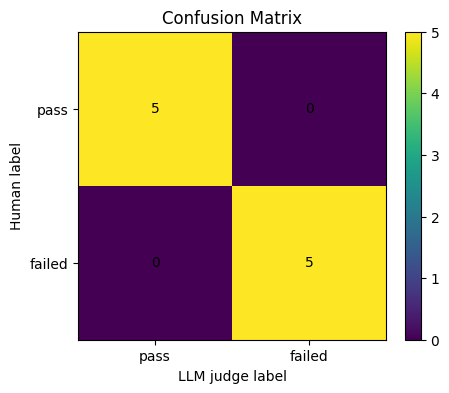

In [23]:
plt.figure(figsize=(5, 4))
plt.imshow(confusion.values)

plt.title("Confusion Matrix")
plt.xlabel("LLM judge label")
plt.ylabel("Human label")

plt.xticks(range(len(confusion.columns)), confusion.columns)
plt.yticks(range(len(confusion.index)), confusion.index)

for i in range(confusion.shape[0]):
    for j in range(confusion.shape[1]):
        plt.text(j, i, confusion.values[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

## 10. Takeaways

No-reference evaluation measures whether an LLM judge can reproduce human judgments.

High agreement suggests the judge can scale evaluation. Low agreement means the criteria or prompt needs improvement.

Disagreements are especially useful: they show where the definition of quality is unclear and help refine the evaluation criteria.

In practice, building a good LLM judge is an iterative process driven by analyzing these errors.